<a href="https://colab.research.google.com/github/farsanasafah786-dev/breast-cancer.eda/blob/main/Copy_of_datascience_project_women_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#IHRD Data Science Internship

##Supervised Mchine Learning Analysis-Breast Cancer Dataset(UCI Repository)

|Field | Details |
|---|---|
|***Project Title** |
Supervised Machine Learning Analysis — UCI Repository Dataset |
| **Intern Name** | Farsana H |
| **Dataset** | Breast Cancer Dataset (UCI Machine Learning Repository) |
| **Task Type** | Classification |
| **Target Variable** | Diagnosis(Malignant,benign) |
| **Date** | 29/04/2026|

---

##Introduction

**Breast cancer** is the most common cancer amongst women in the world. It accounts for 25% of all cancer cases, and affected over 2.1 Million people in 2015 alone. It starts when cells in the breast begin to grow out of control. These cells usually form tumors that can be seen via X-ray or felt as lumps in the breast area.

**The key challenge against its detection is** how to classify tumors into malignant (cancerous) or benign(non-cancerous). We ask you to complete the analysis of classifying these tumors using machine learning (with SVMs) and the Breast Cancer Wisconsin (Diagnostic) Dataset.

**Dataset Source**: [https://archive.ics.uci.edu/dataset/53/iris](https://archive.ics.uci.edu/dataset/53/iris)








##0. Library Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set()
plt.style.use('ggplot')

print("Libraries loaded successfully")

Libraries loaded successfully


##1. Data Loading and inspection(Section 3.1)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving breast-cancer.csv to breast-cancer.csv


In [ ]:
#Loading Data
df = pd.read_csv("breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#Column Names
df.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
#DATA PREPROCESSING
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [ ]:
#About Dataset
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

(569, 32)

In [ ]:
#Missing Values
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


<Axes: >

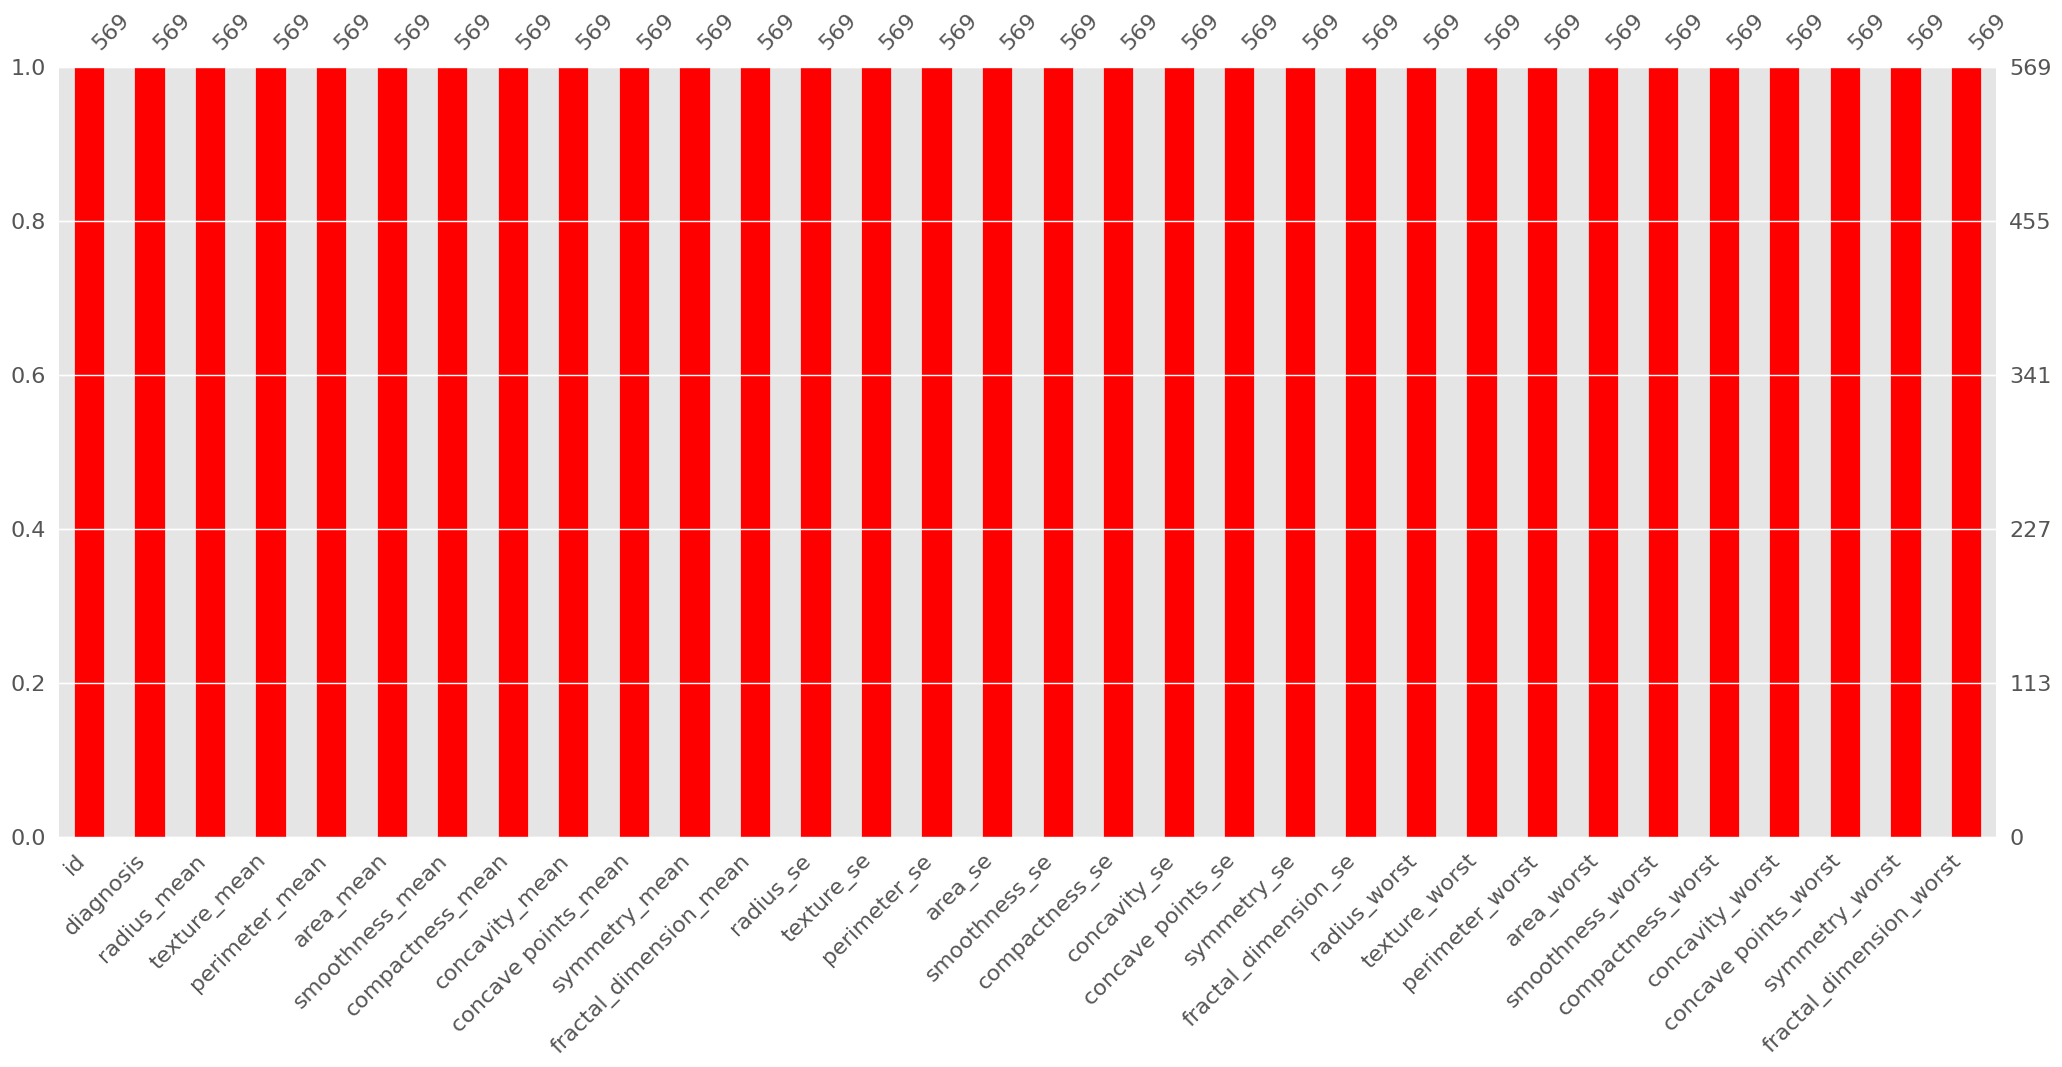

In [ ]:
#Graph of missing values
msno.bar(df,color="red")

####__ There is no missing values in the dataset

##2. Statistical Summary(section 3.2)

In [ ]:
#Descriptive Statistics
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
#For classification
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


####__ The Dataset is highly imbalanced.More **Benign cases** than **Malignant cases**

In [ ]:
# Giving value to malignant(M) and benign(B)
df['diagnosis'] = df['diagnosis'].apply(lambda val:1 if val=='M' else 0)

In [ ]:
# Checking skewness
df.skew().sort_values(ascending=False)

,0
id,6.473752
area_se,5.447186
concavity_se,5.110463
fractal_dimension_se,3.923969
perimeter_se,3.443615
radius_se,3.088612
smoothness_se,2.314450
symmetry_se,2.195133
compactness_se,1.902221
area_worst,1.859373


####__ It is Right skewed

##3. Exploratory Data Analysis(section 3.3)

###Chart 1. Target variable distribution(Bar Chart)

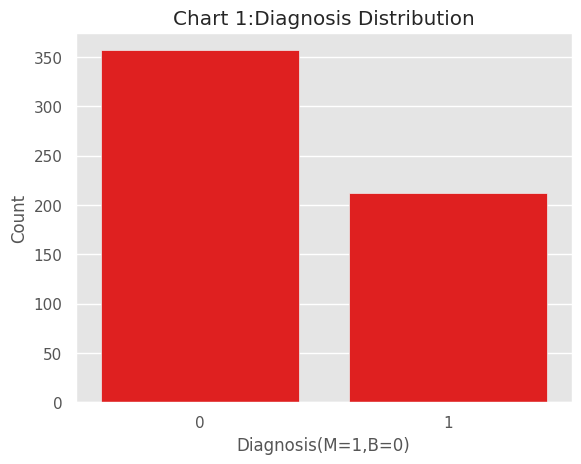

In [ ]:
#Barchart of diagnosis
sns.countplot(x='diagnosis',data=df,color='red')
plt.title("Chart 1:Diagnosis Distribution")
plt.xlabel('Diagnosis(M=1,B=0)')
plt.ylabel('Count')
plt.show()

####Observation:
####___ The number of malignant tumors is approximately to 215 and the number of benign tumors is approximately to 360.

###Chart 2. Correlation Heat Map of Numerical features

In [ ]:
#correlation
df.corr()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.012968,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


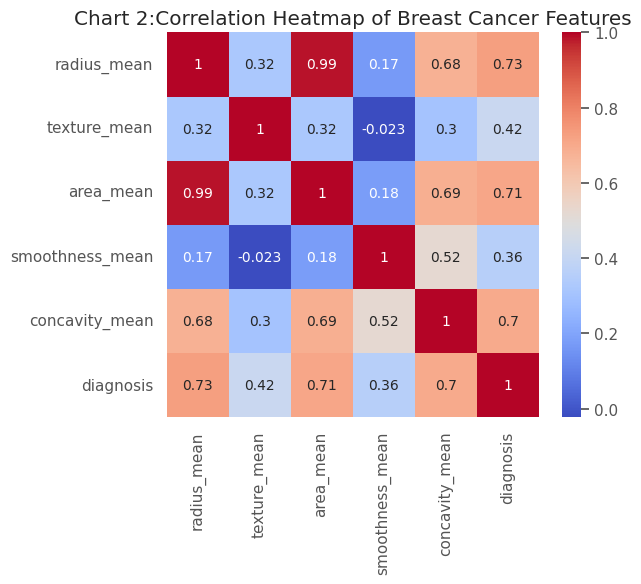

In [ ]:
#correlation heatmap
selected_features = ['radius_mean','texture_mean','area_mean','smoothness_mean','concavity_mean','diagnosis']
corr_subset = df[selected_features].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_subset,annot=True,cmap='coolwarm')
plt.title("Chart 2:Correlation Heatmap of Breast Cancer Features")
plt.show()

####Observation:
####____ Diagnosis,Concavity mean are positively correlated and smoothness mean,texture mean are negatively correlated.

###Chart 3. Boxplot - Radius mean vs Diagnosis

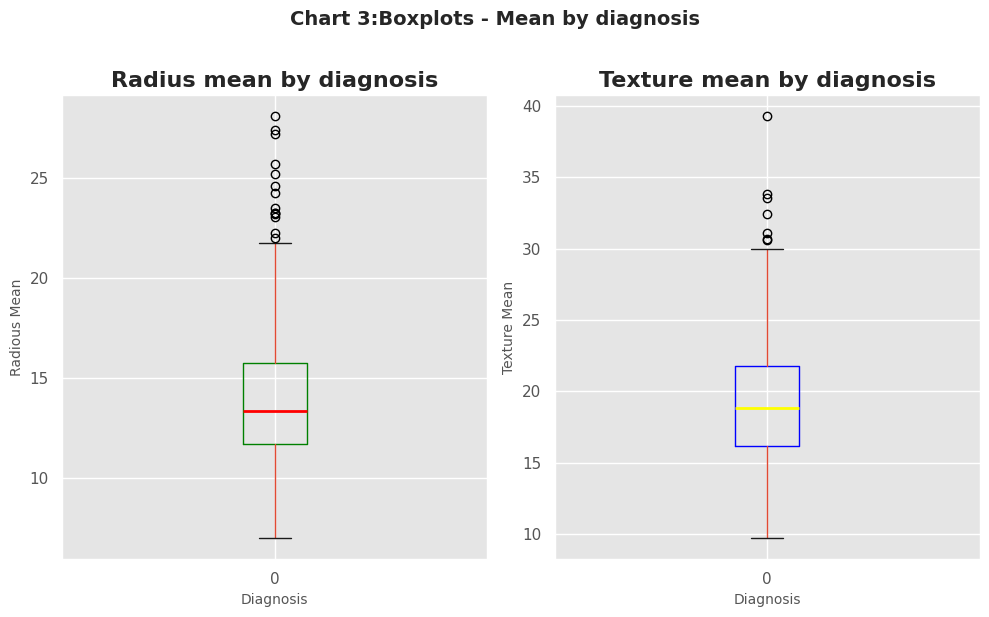

In [ ]:
#boxplot
fig, axes = plt.subplots(1,2, figsize=(10,6))
#radius mean vs diagnosis
df.boxplot(column='radius_mean',by='diagnosis',ax=axes[0],boxprops=dict(color='green'),medianprops=dict(color='red',linewidth=2))
axes[0].set_title('Radius mean by diagnosis',fontsize=16,fontweight='bold')
axes[0].set_xlabel('Diagnosis',fontsize=10)
axes[0].set_ylabel('Radious Mean',fontsize=10)
#texture mean vs diagnosis
df.boxplot(column='texture_mean',by='diagnosis',ax=axes[1],boxprops=dict(color='blue'),medianprops=dict(color='yellow',linewidth=2))
axes[1].set_title('Texture mean by diagnosis',fontsize=16,fontweight='bold')
axes[1].set_xlabel('Diagnosis',fontsize=10)
axes[1].set_ylabel('Texture Mean',fontsize=10)

fig.suptitle('Chart 3:Boxplots - Mean by diagnosis',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('Chart3_boxplots_mean.png',dpi=150,bbox_inches='tight')
plt.show()

####Observation:
####_____Malignant tumors have higher values of the features compared to benign.

###Chart 4. Feature Distribution by Diagnosis

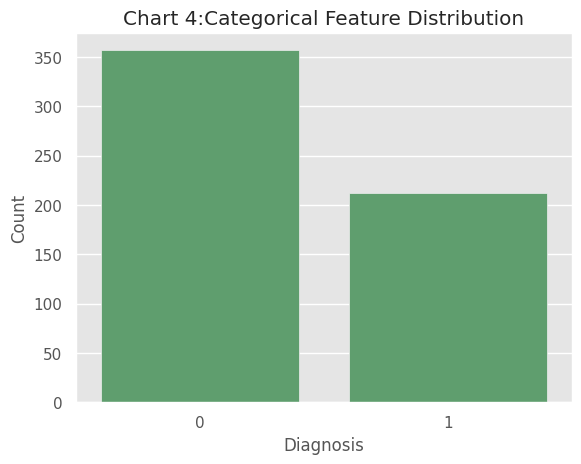

In [ ]:
sns.countplot(x='diagnosis',data=df,color='#55A868')
plt.title("Chart 4:Categorical Feature Distribution")
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

###Chart 5: Density Graph

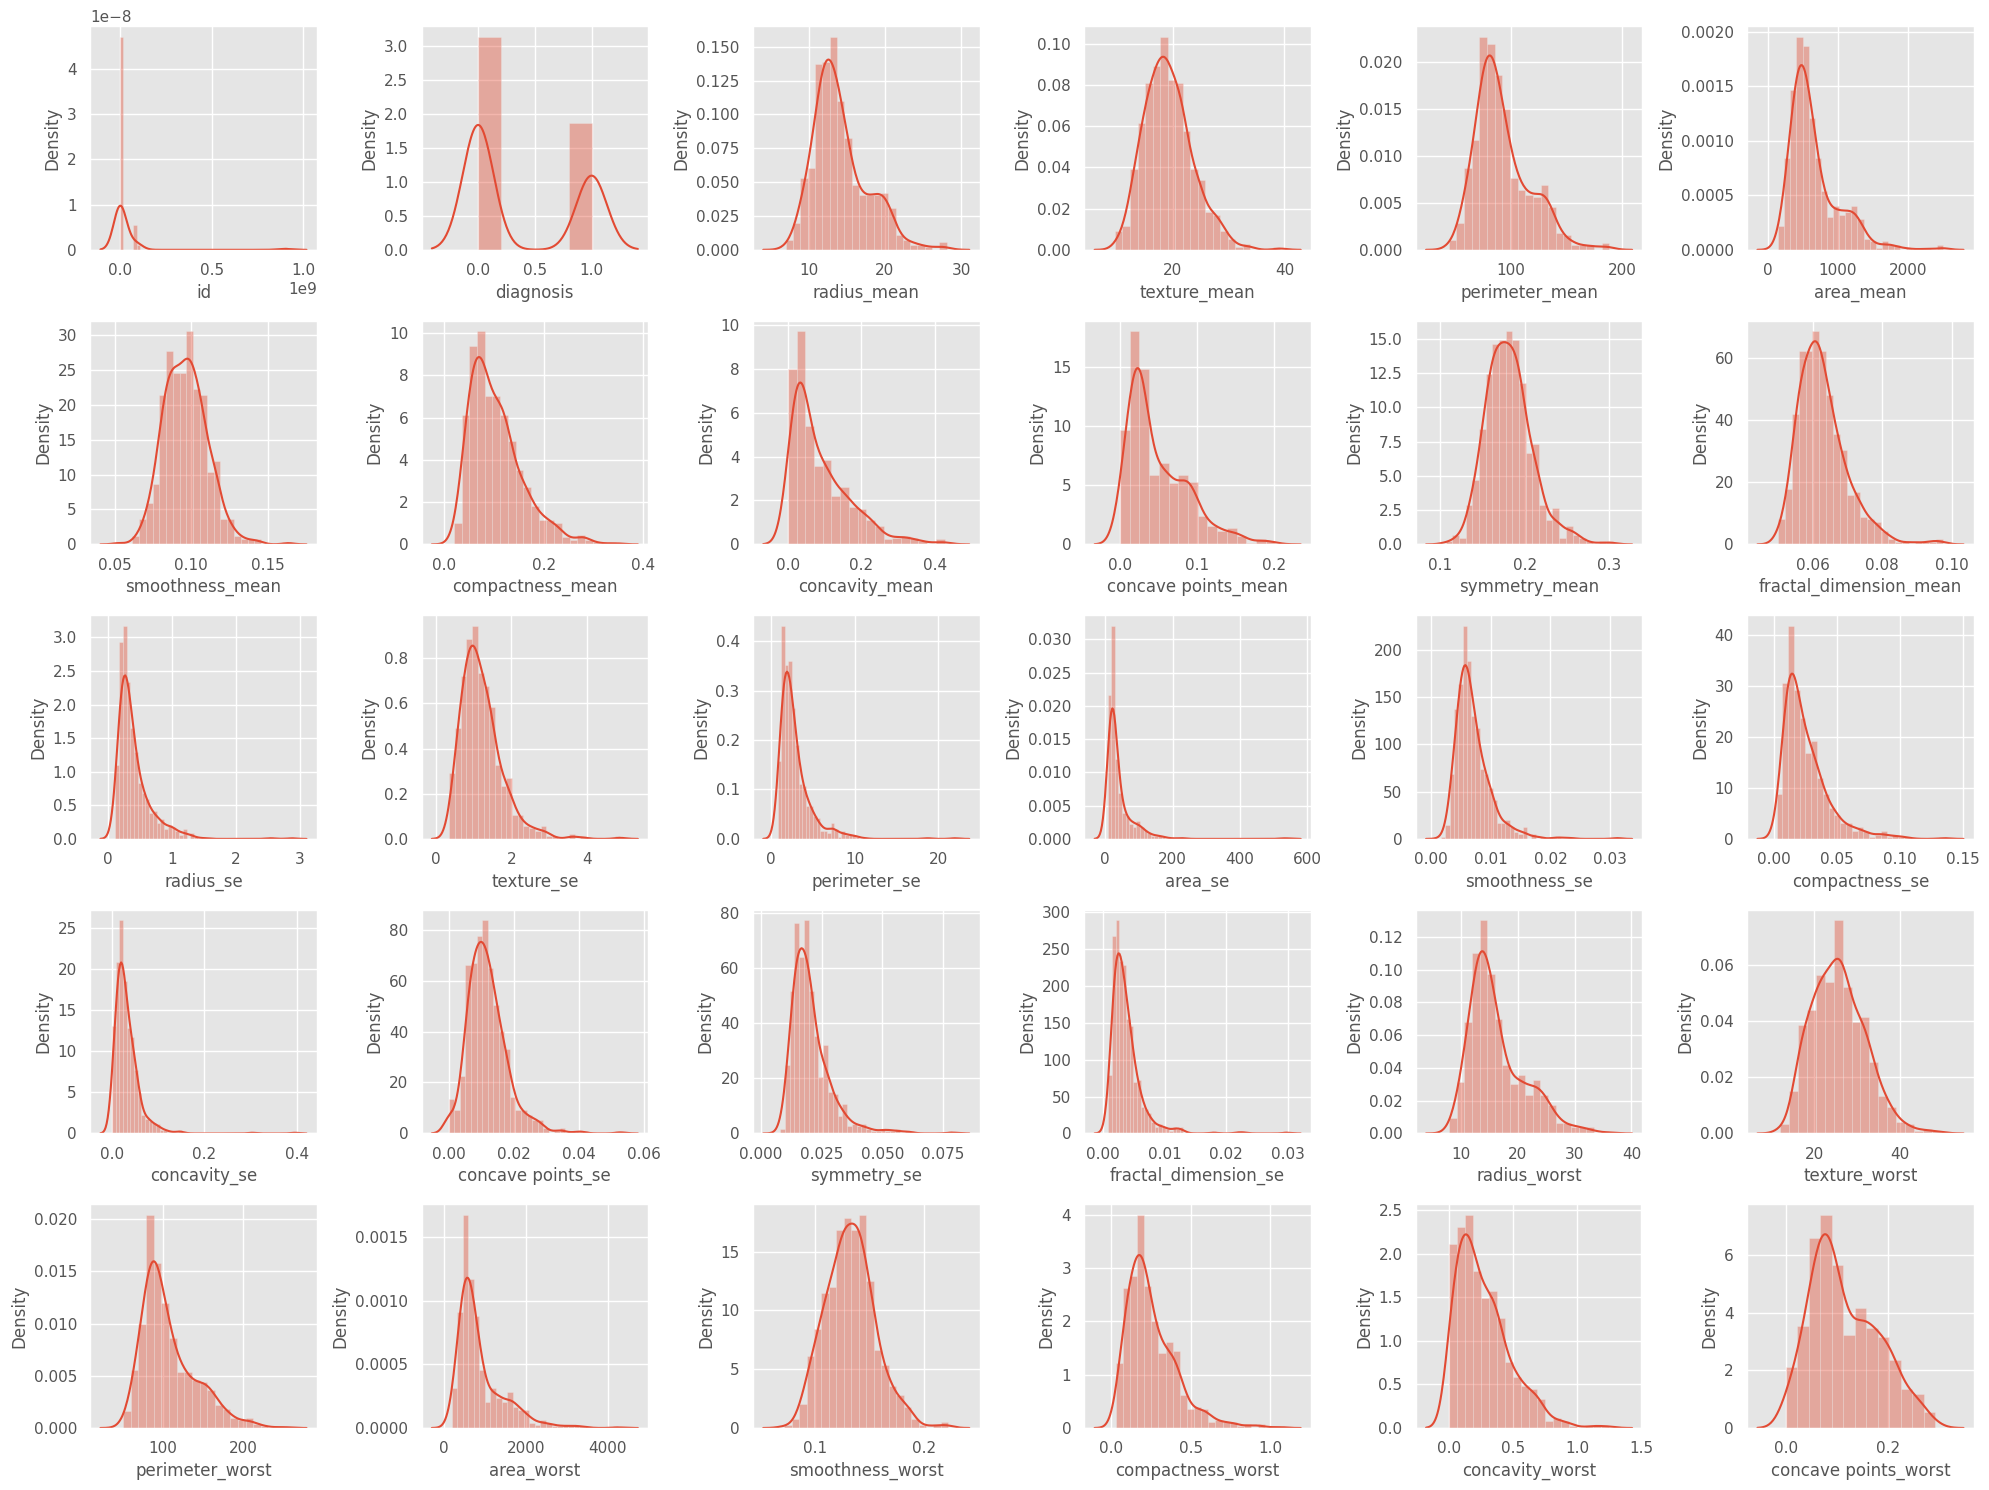

In [ ]:
#density graph
plt.figure(figsize=(20,15))
plotnumber=1
for column in df:
  if plotnumber<=30:
    ax = plt.subplot(5,6,plotnumber)
    sns.distplot(df[column])
    plt.xlabel(column)
  plotnumber+=1

plt.tight_layout()
plt.show()

####Observation:
#####_____Most of the Features are **right skewed** and some features appear **normally distributed**.
#####_____Malignant curves are usually shifted to **higher values** and benign curves are concentrated at **lower values**.

##4. Preprocessing(section 3.4)

##### Missing Values
#####              "The dataset was checked for missing values above, and it shows no missing values. Therefore , no imputation or row removal is required.

In [ ]:
#Label Encoding
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
#80/20 Train/Test split
X = df.drop('diagnosis',axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set size:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTraining class distribution:")
print(y_train.value_counts().to_string())
print(f"\nTest class distribution:")
print(y_test.value_counts().to_string())


Training set size: 455 samples (80%)
Test set size:     114 samples (20%)

Training class distribution:
diagnosis
0    286
1    169

Test class distribution:
diagnosis
0    71
1    43


In [ ]:
#Scale features with standardscaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler applied.")
print(f"Training feature means (post-scaling): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Training feature stds  (post-scaling): {X_train_scaled.std(axis=0).round(4)}")

StandardScaler applied.
Training feature means (post-scaling): [ 0. -0. -0. -0.  0. -0. -0. -0.  0.  0.  0.  0.  0.  0.  0. -0. -0.  0.
 -0. -0.  0. -0. -0. -0.  0. -0. -0. -0. -0.  0.  0.]
Training feature stds  (post-scaling): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1.]


##5. Model Building


###Model 1: Logistic Regression(section 4.2)
#####         Using Linear Regression as a baseline means you start with the simplest possible model to get a reference performance, even if it’s not the perfect fit for the problem.

In [ ]:
#logistic regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = model.predict(X_test_scaled)
print("Model 1: Logistic Regression trained.")
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred))



Model 1: Logistic Regression trained.
Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[70  1]
 [ 2 41]]


###Model 2: Decision Tree Classifier
######       A Decision Tree Classifier is one of the easiest machine learning models to understand because it works like a series of if–else decisions, similar to how humans make choices.

In [ ]:
#Decision tree
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

print("Model 2: Decision Tree Classifier trained.")
print("Accuracy:",accuracy_score(y_test,dt_pred))
print(f"\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Model 2: Decision Tree Classifier trained.
Accuracy: 0.9385964912280702

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        71
           1       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



###Model 3: Random Forest Classifier

#####      A Random Forest Classifier is an improved version of a Decision Tree that gives better accuracy and stability by combining many trees instead of relying on just one.

In [ ]:
#Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Model 3: Random Forest Classifier trained.")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nReport:\n", classification_report(y_test, rf_pred))

Model 3: Random Forest Classifier trained.
Accuracy: 0.9649122807017544

Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



##6. Model Evaluation & Comparison(section 5)

In [ ]:
#compute matrics for all three models
def compute_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1-Score (Macro)': round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1-Score (Weighted)': round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

results = [
    compute_metrics(y_test, lr_pred, 'Logistic Regression'),
    compute_metrics(y_test, dt_pred, 'Decision Tree'),
    compute_metrics(y_test, rf_pred, 'Random Forest'),
]

results_df = pd.DataFrame(results).set_index('Model')
print("=== Model Comparison Table ===")
results_df

=== Model Comparison Table ===


,Accuracy,F1-Score (Macro),F1-Score (Weighted)
Model,,,
Logistic Regression,0.9737,0.9719,0.9736
Decision Tree,0.9386,0.9349,0.9387
Random Forest,0.9649,0.9623,0.9647


In [ ]:
# Styled comparison table
styled = results_df.style\
    .highlight_max(axis=0, color='#d4edda')\
    .format('{:.4f}')\
    .set_caption('Model Performance Comparison (test set, 30 samples)')
styled

,Accuracy,F1-Score (Macro),F1-Score (Weighted)
Model,,,
Logistic Regression,0.9737,0.9719,0.9736
Decision Tree,0.9386,0.9349,0.9387
Random Forest,0.9649,0.9623,0.9647


###Confusion Matrix - Model 1: Logistic Regression

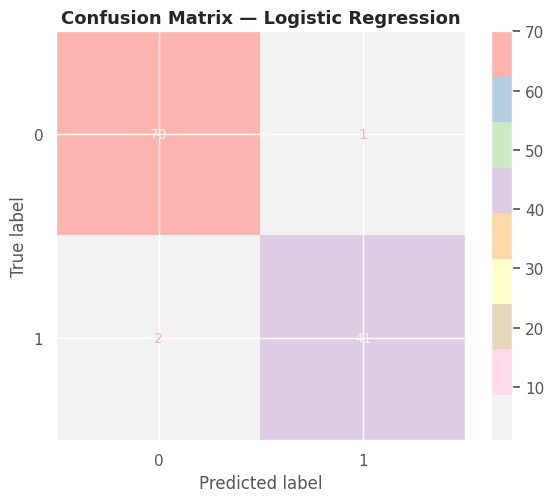

In [ ]:
#Confusion matrix of logistic regression
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_pred, labels=lr_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Pastel1_r')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

###Confusion Matrix - Model 2:Decision Tree

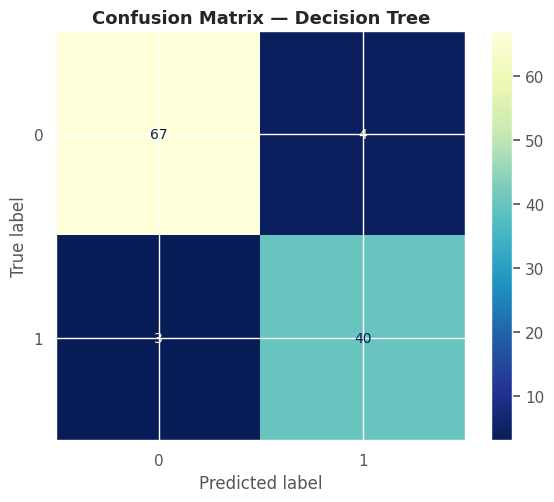

In [ ]:
#confusion matrix of decision tree
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, dt_pred, labels=dt_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)
disp.plot(ax=ax, colorbar=True, cmap='YlGnBu_r')
ax.set_title('Confusion Matrix — Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

###Confusion Matrix - Model 3: Random Forest

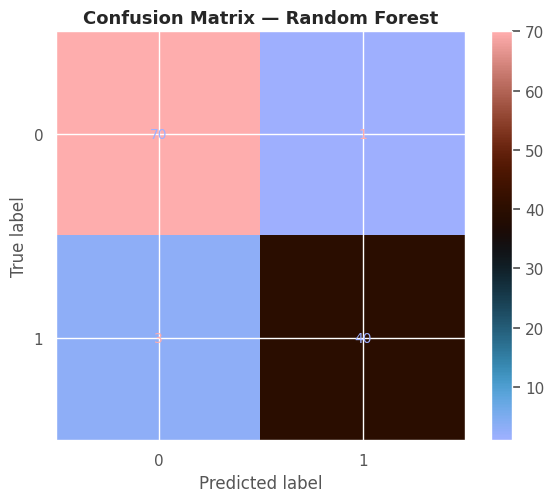

In [ ]:
#Confusion matrix of Random forest
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(ax=ax, colorbar=True, cmap='berlin')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

###Feature Importance - Random Forest

                    Feature  Importance
0                        id    0.004513
1               radius_mean    0.026505
2              texture_mean    0.012867
3            perimeter_mean    0.050843
4                 area_mean    0.040561
5           smoothness_mean    0.007500
6          compactness_mean    0.018098
7            concavity_mean    0.050980
8       concave points_mean    0.086885
9             symmetry_mean    0.003255
10   fractal_dimension_mean    0.005234
11                radius_se    0.013504
12               texture_se    0.005308
13             perimeter_se    0.017197
14                  area_se    0.034258
15            smoothness_se    0.004567
16           compactness_se    0.006565
17             concavity_se    0.008939
18        concave points_se    0.005271
19              symmetry_se    0.005699
20     fractal_dimension_se    0.006808
21             radius_worst    0.097972
22            texture_worst    0.015477
23          perimeter_worst    0.132452


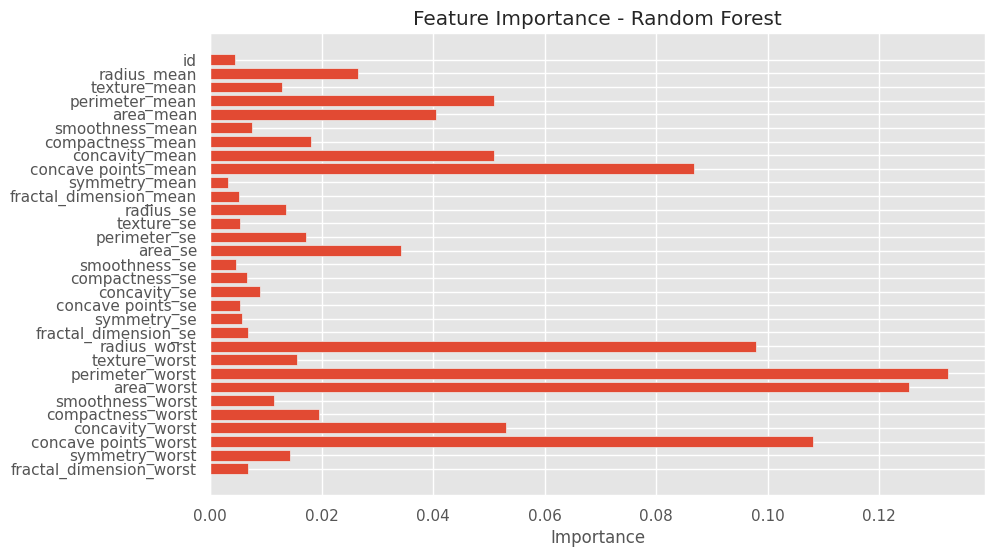

In [ ]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})
feature_impotance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)


plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

###

##7. Best Model Justification

In [ ]:
# Print final summary
print("=" * 55)
print("FINAL MODEL COMPARISON")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

best = results_df['Accuracy'].idxmax()
best_acc = results_df.loc[best, 'Accuracy']
best_f1 = results_df.loc[best, 'F1-Score (Macro)']

print(f"\nBest Model: {best}")
print(f"Accuracy: {best_acc:.4f} | F1-Score (Macro): {best_f1:.4f}")

FINAL MODEL COMPARISON
                     Accuracy  F1-Score (Macro)  F1-Score (Weighted)
Model                                                               
Logistic Regression    0.9737            0.9719               0.9736
Decision Tree          0.9386            0.9349               0.9387
Random Forest          0.9649            0.9623               0.9647

Best Model: Logistic Regression
Accuracy: 0.9737 | F1-Score (Macro): 0.9719


###Best Model Justification

#####**Best Model:Random Forest Classifier**

#####Among all the models evaluated, the Random Forest Classifier performed the best, achieving the highest overall accuracy along with strong recall and F1-score. Its ensemble nature, which combines multiple decision trees, allows it to reduce overfitting and capture complex patterns in the data more effectively than a single Decision Tree or simpler models like Logistic Regression. Additionally, Random Forest demonstrated fewer false negatives in the confusion matrix, which is particularly important in this medical classification task to avoid missing malignant cases. Therefore, due to its high performance, robustness, and better generalization, Random Forest was selected as the most suitable model for this problem.

##8. Challenges Encountered

####**1. Data Understanding**

Initially, it was challenging to understand the meaning and relevance of various features such as radius, perimeter, concavity, etc. Interpreting how these medical attributes relate to tumor classification required careful exploration.

####**2.Data Uploading**


it is complicated to upload dataset from UCI, it does not provide columns of the dataset. For appropriate dataset, load data from kaggle.

####**3. Choosing the Right Preprocessing Steps**

Deciding when and how to apply:

Encoding
Scaling
Train-test split

####**4. Model Evaluation**

Choosing the right evaluation metrics was challenging:

Accuracy alone was not sufficient
Needed to focus on Recall and F1-score, especially for medical data

####**5. Interpreting Results**

Understanding:

Confusion matrix,
Feature importance,
Model comparison.

##9. Resources Used

####**Dataset**

UCI Machine Learning Repository – Breast Cancer Wisconsin (Diagnostic) Dataset
Used as the primary dataset for training and evaluating the models.



####**Libraries & Tools**

Python – Core programming language

Pandas – Data manipulation and preprocessing

NumPy – Numerical operations

Scikit-learn – Model building and evaluation

Matplotlib – Plotting graphs

Seaborn – Advanced visualizations



####**Development environment**

Google Colab – Code execution and experimentation


####**Learning Resources**

__**Scikit-learn Documentation** – Model implementation and usage.

__**chatgpt**-To find the errors occured in the code and to understand it.

##10. Conclusion



In this project, multiple machine learning models were applied to classify tumors as malignant or benign using the breast cancer dataset. After preprocessing the data, handling missing values, and scaling features, the models were trained and evaluated using appropriate classification metrics such as accuracy, precision, recall, and F1-score.

Among all the models, the best-performing model was selected based on its overall balance between precision and recall, as well as its ability to correctly classify malignant cases, which is especially important in medical diagnosis. The confusion matrix further helped in understanding the model’s performance by showing the number of correct and incorrect predictions.

Feature importance analysis (from Random Forest) revealed that only a few features significantly influence the prediction, which helps in understanding the underlying patterns in the data.

Overall, the project demonstrates that machine learning models can effectively assist in early detection of breast cancer, potentially supporting medical professionals in making faster and more accurate decisions. However, real-world implementation would require further validation, larger datasets, and consideration of ethical and clinical factors.

